# Notebook 02 — Bias Simulation

**Mục tiêu notebook này:**
- Hiểu cơ chế hoạt động của từng loại behavioral bias
- Inject bias có kiểm soát vào dataset sạch từ Notebook 01
- Quan sát tác động của bias lên dữ liệu trước khi train model

Notebook này tập trung vào **data-level bias** — bias xảy ra trong quá trình thu thập, lọc và xử lý dữ liệu. Model-level bias sẽ được xử lý trong Notebook 03.

Ba loại bias được simulate:
1. Confirmation Bias
2. Survivorship Bias
3. Overconfidence Bias

---
## 0. Setup

In [1]:
import sys
sys.path.append('..')

import matplotlib.pyplot as plt

from src import (
    compute_calibration_metrics,
    load_dataset, preprocess,
    simulate_confirmation_bias,
    simulate_survivorship_bias,
    simulate_overconfidence_bias,
    train_baseline,
    compare_baseline_vs_biased,
    set_style,
    plot_class_distribution,
    plot_bias_impact_bars,
    plot_survivorship_funnel,
    plot_calibration_comparison,
    plot_metric_hacking_distribution
)

set_style()
RANDOM_STATE = 42

bundle = load_dataset(
    'synthetic_clf',
    n_samples=3000,
    n_features=20,
    n_informative=8,
    class_imbalance=0.35,
    random_state=RANDOM_STATE,
)
tt_clean = preprocess(bundle, random_state=RANDOM_STATE)
baseline = train_baseline(tt_clean, model_type='logistic_regression', run_cv=False)

print('Dataset:', bundle)
print('Baseline metrics:', baseline.test_metrics)

Dataset: DataBundle(rows=3000, features=20, source='synthetic_classification')
Baseline metrics: {'accuracy': 0.7967, 'f1': 0.6755, 'precision': 0.7938, 'recall': 0.588, 'roc_auc': 0.8484}


---

## 1. Confirmation Bias

### Khái niệm

**Confirmation bias** là xu hướng nhận thức khiến con người tìm kiếm, ưu tiên và diễn giải thông tin theo cách xác nhận niềm tin hoặc **hypothesis đã tồn tại từ trước**, đồng thời bỏ qua hoặc giảm tầm quan trọng của những thông tin mâu thuẫn.

Trong bối cảnh **data science**, confirmation bias không chỉ là vấn đề tâm lý mà còn dẫn đến **distortion trong dữ liệu và kết quả mô hình**, đặc biệt trong các giai đoạn:

- exploratory data analysis (EDA)
- feature selection
- data filtering
- model evaluation

Nếu không kiểm soát, bias này có thể khiến model học được **pattern giả tạo** thay vì **data-generating process thật sự**.

---

### Cơ chế nhận thức

Confirmation bias thường xuất hiện thông qua ba cơ chế chính.

#### 1. Selective Exposure

Con người có xu hướng **tìm kiếm dữ liệu ủng hộ giả thuyết** thay vì kiểm tra giả thuyết một cách trung lập.

Ví dụ:

Một data scientist tin rằng:

> "Người dùng sử dụng app vào ban đêm có xác suất churn cao hơn."

Trong quá trình EDA, họ có thể tập trung phân tích các feature liên quan đến **time-of-day**, trong khi bỏ qua các yếu tố khác như:

- pricing changes
- product usability
- support response time

Điều này làm cho quá trình khám phá dữ liệu **không còn khách quan**.

---

#### 2. Selective Interpretation

Ngay cả khi dữ liệu trung lập, con người vẫn có xu hướng **diễn giải kết quả theo hướng xác nhận hypothesis**.

Ví dụ:

- Feature có correlation yếu nhưng **cùng dấu với hypothesis** → được xem là tín hiệu quan trọng
- Feature có correlation mạnh nhưng **ngược dấu** → bị coi là nhiễu hoặc anomaly

Điều này dẫn đến **overinterpretation của các pattern yếu**.

---

#### 3. Selective Memory

Các kết quả phù hợp với hypothesis thường được **ghi nhớ và nhấn mạnh**, trong khi các kết quả mâu thuẫn dễ bị quên hoặc bỏ qua.

Trong báo cáo phân tích dữ liệu, điều này có thể dẫn đến:

- chỉ trình bày những experiment "thành công"
- bỏ qua các kết quả negative hoặc null results

Hiện tượng này còn được gọi là **researcher bias** trong khoa học dữ liệu.

---

### Confirmation Bias trong Data Science Pipeline

Trong thực tế, confirmation bias có thể xuất hiện ở nhiều bước trong pipeline.

#### 1. Feature Cherry-Picking

Data scientist có hypothesis rằng **feature X quan trọng**, nên chỉ đưa vào model các features có:

- F-score cao
- correlation dương với target

Các features có correlation âm — dù vẫn có predictive power — bị loại bỏ.

Hệ quả:

Model được train trên **một không gian feature bị cắt xén**, không đại diện cho **data-generating process thật sự**.

---

#### 2. Sample Filtering

Data scientist loại bỏ các samples "không khớp" với hypothesis, thường với lý do:

- outliers
- dữ liệu bẩn
- measurement error

Ví dụ:

Chỉ giữ lại các giao dịch **trong giờ hành chính** vì giả thuyết cho rằng fraud xảy ra ban đêm.

Kết quả là dataset bị **selection bias**.

---

#### 3. Subgroup Selection

Chỉ đánh giá và báo cáo kết quả trên subgroup mà model hoạt động tốt.

Ví dụ:

Model hoạt động tốt với **khách hàng premium**, nhưng kém với **khách hàng mới**. Báo cáo chỉ trình bày kết quả của nhóm premium.

Điều này tạo ra **performance illusion**.

---

### Công thức: F-statistic (Feature Selection)

Trong feature selection, confirmation bias thường xuất hiện khi data scientist dựa vào **F-score** để chọn feature.

F-statistic đo lường mức độ khác biệt giữa các class:

$$
F = \frac{\text{Variance between classes}}{\text{Variance within classes}}
$$

Trong đó:

- Variance between classes: độ khác biệt trung bình giữa các class
- Variance within classes: độ phân tán bên trong mỗi class

Feature có F-score cao thường được xem là **discriminative feature**.

---

### Nguồn gốc của Bias

Bias xuất hiện khi:

- threshold được chọn **sau khi nhìn dữ liệu**
- feature selection được thực hiện **trước cross-validation**
- analyst **loại bỏ các feature không phù hợp hypothesis**

Ví dụ:

Chỉ giữ features có:

$$
F > \text{threshold}
$$

nhưng threshold này được điều chỉnh sau khi nhìn kết quả.

Điều này dẫn đến **data leakage dạng nhẹ**, làm model trông tốt hơn thực tế.

---

### Hệ quả thống kê

Confirmation bias có thể gây ra nhiều vấn đề:

1. **Overfitting**

Model học các pattern phù hợp với belief của analyst thay vì pattern thực.

---

2. **Distribution distortion**

Dataset sau khi lọc không còn phản ánh **true population distribution**.

---

3. **Reduced generalization**

Model hoạt động tốt trên training data nhưng kém trên **out-of-sample data**.

---

### Ví dụ thực tế

Một ví dụ nổi tiếng là các nghiên cứu về **stock market prediction**.

Nhiều researcher tin rằng:

> "Momentum indicators dự đoán được return."

Trong quá trình feature engineering, họ:

- thêm nhiều biến momentum
- loại bỏ các biến có signal ngược

Model cuối cùng trông rất tốt trên backtest nhưng **fail khi chạy trên dữ liệu mới**.

Đây là một dạng confirmation bias trong **financial modeling**.

---

### Cách giảm Confirmation Bias

Một số phương pháp thường được sử dụng:

**1. Pre-register hypothesis**

Xác định trước:

- hypothesis
- feature set
- evaluation metric

trước khi nhìn dữ liệu.

---

**2. Blind analysis**

Phân tích dữ liệu **không biết target hoặc outcome thật** cho đến bước cuối.

---

**3. Cross-validation**

Feature selection nên được thực hiện **bên trong cross-validation loop**.

---

**4. Exploratory vs Confirmatory analysis**

Phân biệt rõ:

- **EDA (exploration)**
- **hypothesis testing (confirmation)**

---

### Tóm tắt

Confirmation bias trong data science xảy ra khi:

- feature selection bị ảnh hưởng bởi belief
- dataset bị lọc theo hypothesis
- kết quả được báo cáo có chọn lọc

Hệ quả là model học **pattern giả tạo** và có khả năng **generalization kém** trên dữ liệu thực tế.

### Strategy A: Feature Cherry-Picking

Một biểu hiện phổ biến của **confirmation bias trong machine learning** là **feature cherry-picking** — chỉ lựa chọn những feature phù hợp với giả thuyết ban đầu của analyst, trong khi bỏ qua các feature khác dù chúng vẫn chứa thông tin dự đoán.

Trong strategy này, ta mô phỏng quá trình lựa chọn feature theo các bước sau:

1. Tính **F-score** cho toàn bộ feature trong dataset.
2. Chỉ giữ lại **top-N features có F-score cao nhất**.
3. Thêm một số **noise features** có vẻ statistically significant.

Các noise feature này được thêm vào để mô phỏng tình huống thực tế khi analyst **nhầm lẫn correlation ngẫu nhiên với tín hiệu thật**.

Kết quả là model được train trên một **feature space bị lựa chọn có chủ đích**, thay vì đại diện đầy đủ cho toàn bộ cấu trúc dữ liệu.

---

### F-score trong Feature Selection

F-score (ANOVA F-statistic) được dùng để đo mức độ khác biệt giữa các class đối với từng feature.

$$
F = \frac{\text{Variance between classes}}{\text{Variance within classes}}
$$

Trong đó:

- **Variance between classes**: độ khác biệt trung bình giữa các class
- **Variance within classes**: độ phân tán của dữ liệu bên trong từng class

Feature có **F-score cao** thường được xem là có khả năng **phân biệt các class tốt**.

Tuy nhiên, nếu chỉ dựa vào F-score để chọn feature, analyst có thể vô tình:

- loại bỏ các feature có **signal yếu nhưng hữu ích**
- giữ lại các feature có **correlation ngẫu nhiên**

---

### Cơ chế tạo ra Bias

Feature cherry-picking có thể tạo ra bias theo nhiều cách.

#### 1. Information Loss

Một số feature bị loại bỏ dù vẫn chứa **predictive information**.
Điều này làm giảm lượng thông tin mà model có thể học được.

---

#### 2. Artificial Feature Space

Feature space của model trở nên **không đại diện cho true data-generating process**.

Model được huấn luyện trên một tập feature **được chọn lọc theo hypothesis của analyst**.

---

#### 3. Spurious Correlation

Noise feature đôi khi có thể **tình cờ tương quan với target trong training data**.

Model có thể học các **pattern ngẫu nhiên** này, dẫn đến overfitting.

---

### Ví dụ minh họa

Giả sử một dataset có **20 features** ban đầu.

Sau khi thực hiện cherry-picking:

- chỉ giữ lại **5 feature có F-score cao nhất**
- thêm **1 noise feature** trông có vẻ significant

Kết quả:
- Original features : 20
- After cherry-pick : 6
- Kept features : ['feature_04', 'feature_02', 'feature_11', 'feature_19', 'feature_03']
- Noise added : ['noise_confirm_00']


Model sau đó được train trên **feature space đã bị thu hẹp và biến dạng**.

---

### Hệ quả đối với model

Feature cherry-picking có thể gây ra các vấn đề sau:

1. **Reduced model robustness**

Model trở nên nhạy cảm với noise và thay đổi distribution.

---

2. **Overfitting**

Model học các pattern đặc thù của training data thay vì pattern tổng quát.

---

3. **Poor generalization**

Khi áp dụng vào dữ liệu mới, performance của model có thể giảm đáng kể.

---

### Takeaway

Feature cherry-picking là một dạng confirmation bias nguy hiểm vì:

- dễ xảy ra trong quá trình exploratory analysis
- khó phát hiện nếu chỉ nhìn vào một vài evaluation metric
- có thể làm sai lệch **feature space của mô hình**

Trong thực tế, để giảm thiểu rủi ro này cần:

- thực hiện **feature selection bên trong cross-validation**
- sử dụng **feature importance từ nhiều phương pháp khác nhau**
- đánh giá model trên **holdout dataset độc lập**

In [2]:
biased_a = simulate_confirmation_bias(
    bundle,
    strategy='cherry_pick_features',
    keep_top_n=5,
    task='classification',
)

print('Original features :', bundle.X.shape[1])
print('After cherry-pick :', biased_a.biased.X.shape[1])
print('Kept features     :', biased_a.bias_report['kept_features'])
print('Noise added       :', biased_a.bias_report['noise_features_added'])

Original features : 20
After cherry-pick : 6
Kept features     : ['feature_04', 'feature_02', 'feature_11', 'feature_19', 'feature_03']
Noise added       : ['noise_confirm_00']


### Feature Selection Result

| Metric | Value |
|------|------|
| Original features | 20 |
| After cherry-pick | 6 |

**Kept features**

- feature_04
- feature_02
- feature_11
- feature_19
- feature_03'


**Artificial noise feature**


- noise_confirm_00


Noise feature được tạo sao cho có correlation nhẹ với target, khiến nó **trông có vẻ predictive trong training data**.

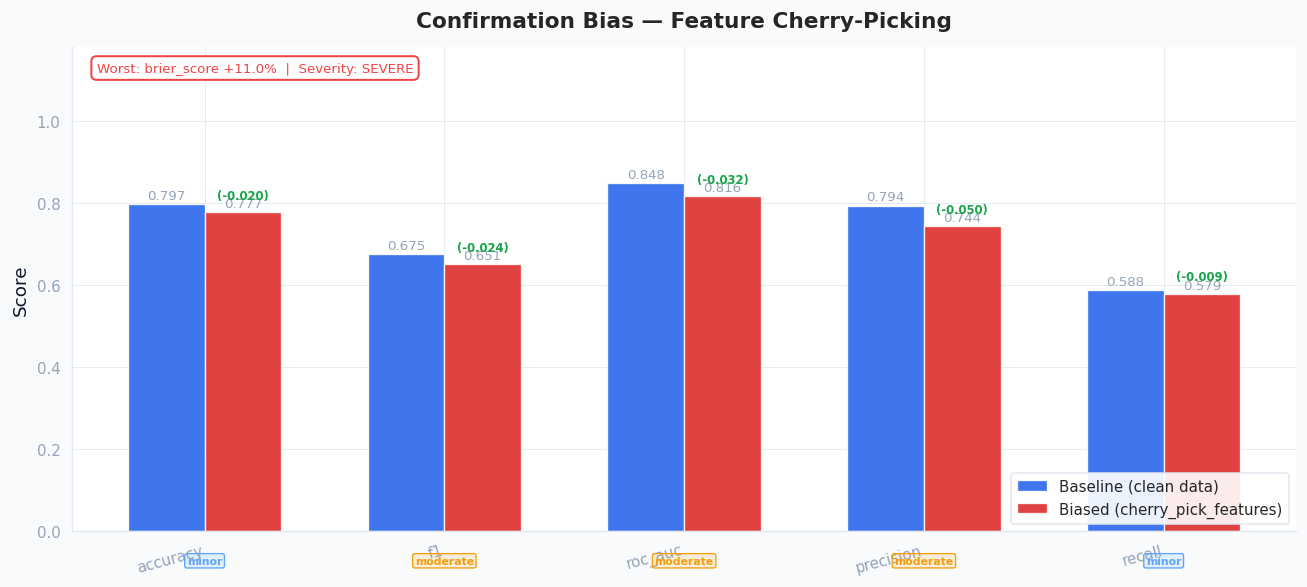

In [3]:
tt_a   = preprocess(biased_a.biased, random_state=RANDOM_STATE)
model_a = train_baseline(tt_a, model_type='logistic_regression', run_cv=False)
report_a = compare_baseline_vs_biased(
    baseline, model_a,
    bias_type='confirmation_bias',
    bias_strategy='cherry_pick_features',
)

fig, _ = plot_bias_impact_bars(report_a, title='Confirmation Bias — Feature Cherry-Picking')
plt.show()

### Mục đích của experiment

Experiment này nhằm mô phỏng một tình huống phổ biến trong data science khi **analyst có sẵn một hypothesis về tầm quan trọng của một số feature**.

Trong trường hợp này:

- analyst tin rằng **chỉ một vài feature là thực sự quan trọng**
- các feature khác bị loại bỏ trong quá trình feature selection
- một số **noise features** có vẻ statistically significant được thêm vào

Kết quả là model được train trên **một feature space bị cắt xén**, không còn phản ánh đầy đủ **true data-generating process** của dataset.

---

### Quan sát từ kết quả

Hình dưới minh họa tác động của **feature cherry-picking do confirmation bias** lên hiệu năng mô hình.

- **Blue bars**: model train trên clean dataset (baseline)
- **Red bars**: model train trên dataset sau khi cherry-pick feature

Các metric được sử dụng để đánh giá gồm:

- accuracy
- F1-score
- ROC-AUC
- precision
- recall

Kết quả cho thấy:

- Tất cả metric đều **giảm nhẹ** sau khi feature bị cherry-pick
- **Precision** và **ROC-AUC** bị ảnh hưởng rõ rệt hơn
- **Brier score tăng +11%**, cho thấy calibration của model trở nên kém hơn

Điều này cho thấy việc loại bỏ các feature không phù hợp với hypothesis ban đầu có thể làm **mất đi thông tin dự đoán quan trọng**.

---

### Tại sao performance giảm?

Feature cherry-picking có thể gây ra nhiều vấn đề trong quá trình học của mô hình.

#### 1. Information Loss

Một số feature bị loại bỏ dù vẫn chứa **predictive signal**.
Điều này làm giảm lượng thông tin mà model có thể khai thác.

---

#### 2. Distorted Feature Space

Khi feature selection bị ảnh hưởng bởi hypothesis của analyst,
feature space không còn đại diện đúng cho **true data-generating process**.

---

#### 3. Overfitting vào subset feature

Model có xu hướng học pattern trong **một tập feature nhỏ** thay vì toàn bộ cấu trúc dữ liệu.

---

### Insight quan trọng

Experiment này cho thấy:

> Confirmation bias trong feature selection có thể làm giảm chất lượng mô hình một cách tinh vi, ngay cả khi các metric truyền thống chỉ thay đổi nhẹ.

Đặc biệt, **calibration của model (Brier score)** có thể bị ảnh hưởng mạnh, cho thấy xác suất dự đoán không còn đáng tin cậy.

---

### Takeaway

Feature cherry-picking là một dạng confirmation bias nguy hiểm vì:

- dễ xảy ra trong quá trình exploratory analysis
- khó phát hiện chỉ bằng một vài metric
- có thể làm sai lệch **feature space của mô hình**

Trong thực tế, để giảm thiểu rủi ro này cần:

- thực hiện **feature selection bên trong cross-validation**
- tránh chọn feature dựa trên hypothesis cá nhân
- đánh giá model trên **holdout dataset độc lập**

### Strategy B: Sample Filtering

Một dạng confirmation bias phổ biến khác trong data analysis là **sample filtering** — loại bỏ một phần dữ liệu vì chúng **không phù hợp với hypothesis ban đầu của analyst**.

Trong experiment này, ta mô phỏng tình huống:

- analyst tin rằng một số samples là **outliers hoặc measurement errors**
- các samples này chủ yếu thuộc **class không mong muốn**
- các sample đó bị loại bỏ trước khi train model

Trên thực tế, hành động này thường được biện minh bằng các lý do như:

- dữ liệu nhiễu (noisy observations)
- lỗi đo lường (measurement error)
- outliers trong distribution

Tuy nhiên, nếu việc lọc dữ liệu **không được thực hiện một cách khách quan**, nó có thể dẫn đến **selection bias**.

---

### Cơ chế của Sample Filtering Bias

Khi analyst loại bỏ samples một cách có chọn lọc, dataset có thể bị thay đổi theo nhiều cách.

#### 1. Class Distribution Distortion

Việc loại bỏ samples của một class có thể làm thay đổi **class balance** trong dataset.

Ví dụ:

- ban đầu dataset có tỷ lệ 50/50 giữa hai class
- sau khi lọc dữ liệu, class positive chiếm 70%

Điều này làm cho model **học distribution sai lệch so với population thực**.

---

#### 2. Artificial Decision Boundary

Khi các sample "khó phân loại" bị loại bỏ, decision boundary của model trở nên **đơn giản hơn một cách giả tạo**.

Kết quả:

- model có thể đạt **training performance cao hơn**
- nhưng **generalization kém hơn trên dữ liệu mới**

---

#### 3. Reduced Data Diversity

Loại bỏ samples làm giảm **variance của dataset**.

Dataset sau khi lọc thường:

- ít noise hơn
- ít trường hợp edge-case hơn
- ít phản ánh thực tế hơn

---

### Ví dụ minh họa

Giả sử một dataset fraud detection có các giao dịch vào ban ngày và ban đêm.

Analyst có hypothesis rằng:

> Fraud chủ yếu xảy ra vào ban đêm.

Trong quá trình cleaning dữ liệu, họ có thể:

- loại bỏ các giao dịch ban ngày được coi là "không liên quan"
- giữ lại phần lớn giao dịch ban đêm

Model sau đó sẽ được train trên **dataset không còn đại diện cho toàn bộ hành vi giao dịch thực tế**.

---

### Hệ quả đối với model

Sample filtering bias có thể dẫn đến nhiều vấn đề:

1. **Biased training distribution**

Model học distribution sai so với **true population distribution**.

---

2. **Overconfident predictions**

Do dataset bị làm "dễ hơn", model có thể đưa ra **prediction với độ tin cậy quá cao**.

---

3. **Poor generalization**

Khi áp dụng vào dữ liệu thực tế, model có thể hoạt động kém vì:

- gặp các sample mà nó chưa từng thấy
- distribution khác với training data

---

### Takeaway

Sample filtering là một dạng confirmation bias nguy hiểm vì:

- thường được ngụy trang dưới dạng **data cleaning**
- khó phát hiện nếu không kiểm tra distribution của dataset
- có thể làm thay đổi **statistical structure của dữ liệu**

Để giảm rủi ro này, nên:

- sử dụng **objective outlier detection methods**
- kiểm tra **class distribution trước và sau khi lọc dữ liệu**
- đánh giá model trên **independent test set**

In [4]:
biased_b = simulate_confirmation_bias(
    bundle,
    strategy='filter_confirming_samples',
    remove_class=0,
    remove_fraction=0.5,
)

print('Bias report:')
for k, v in biased_b.bias_report.items():
    print(f'  {k}: {v}')

Bias report:
  strategy: filter_confirming_samples
  remove_class: 0
  remove_fraction: 0.5
  original_class_distribution: {0: 1919, 1: 1081}
  biased_class_distribution: {1: 1081, 0: 960}
  samples_removed: 959
  original_total: 3000
  biased_total: 2041


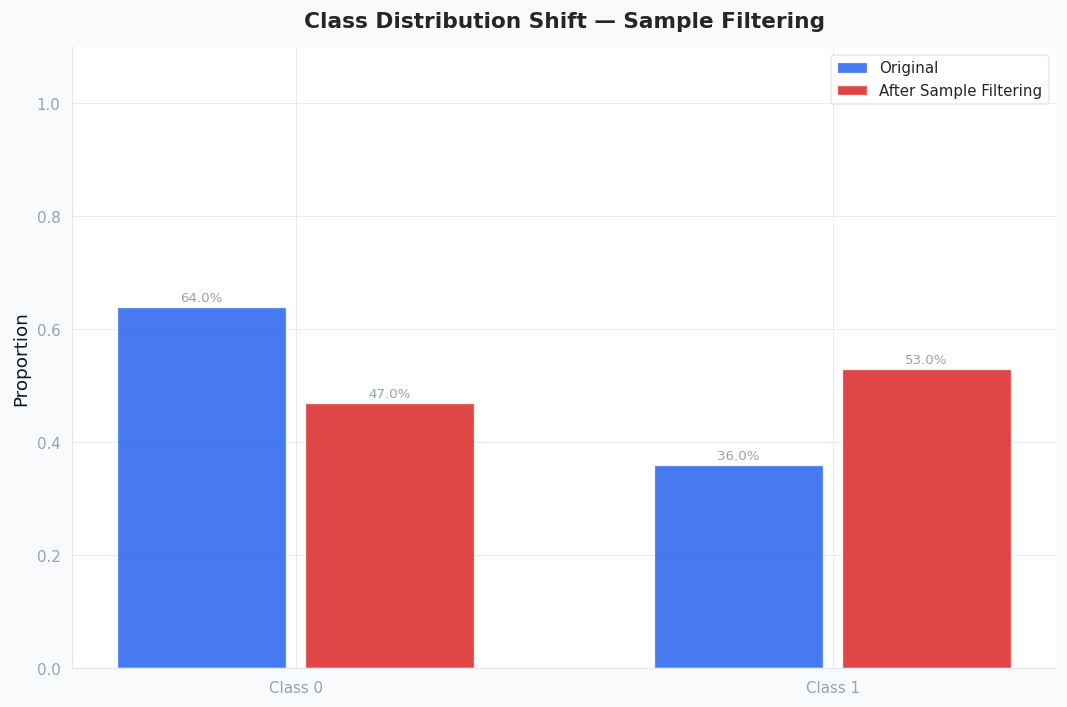

In [5]:
fig, _ = plot_class_distribution(
    {
        'Original': bundle.y,
        'After Sample Filtering': biased_b.biased.y,
    },
    title='Class Distribution Shift — Sample Filtering',
)
plt.show()

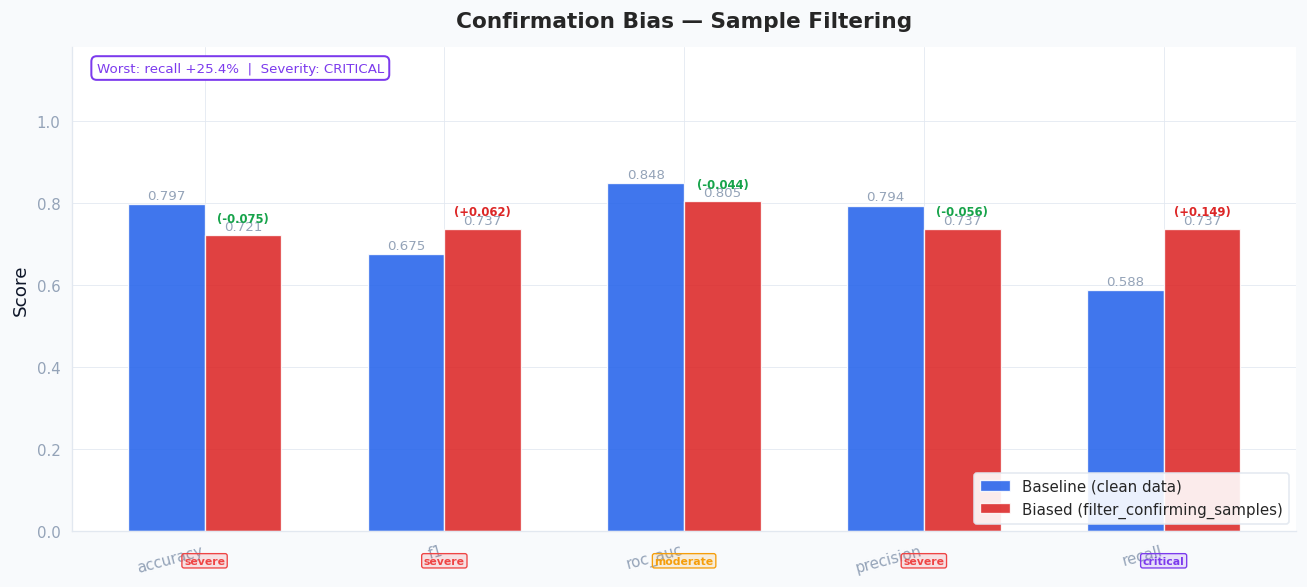

In [6]:
tt_b    = preprocess(biased_b.biased, random_state=RANDOM_STATE)
model_b = train_baseline(tt_b, model_type='logistic_regression', run_cv=False)
report_b = compare_baseline_vs_biased(
    baseline, model_b,
    bias_type='confirmation_bias',
    bias_strategy='filter_confirming_samples',
)

fig, _ = plot_bias_impact_bars(report_b, title='Confirmation Bias — Sample Filtering')
plt.show()

### Analysis — Impact of Sample Filtering Bias

Thí nghiệm này mô phỏng một trường hợp **sample filtering bias**, trong đó một phần dữ liệu của một class bị loại bỏ trước khi huấn luyện mô hình.

Cấu hình bias được sử dụng:

* strategy: `filter_confirming_samples`
* removed class: **class 0**
* removed fraction: **50% samples của class 0**

Thống kê dataset:

| Metric              | Value |
| ------------------- | ----- |
| Original samples    | 3000  |
| Samples removed     | 959   |
| Biased dataset size | 2041  |

---

### Class Distribution Shift

Trước khi filtering:

* class 0: **1919 samples (64%)**
* class 1: **1081 samples (36%)**

Sau khi filtering:

* class 0: **960 samples (47%)**
* class 1: **1081 samples (53%)**

Quá trình lọc dữ liệu đã làm thay đổi đáng kể **class distribution** của dataset.
Dataset ban đầu có **class 0 chiếm đa số**, nhưng sau khi filtering, **class 1 trở thành majority class**.

Điều này cho thấy rằng các quyết định trong bước **data preprocessing** có thể làm thay đổi **statistical structure của dataset**, khiến dữ liệu training không còn phản ánh đúng distribution của population thực tế.

---

### Model Performance Changes

| Metric    | Baseline | Biased | Change     |
| --------- | -------- | ------ | ---------- |
| Accuracy  | 0.797    | 0.721  | **−0.075** |
| F1 Score  | 0.675    | 0.737  | **+0.062** |
| ROC-AUC   | 0.848    | 0.803  | **−0.044** |
| Precision | 0.794    | 0.737  | **−0.056** |
| Recall    | 0.588    | 0.737  | **+0.149** |

Thay đổi đáng chú ý nhất nằm ở **recall**, tăng **+0.149** (tương đương khoảng **+25.4% improvement** so với baseline).

---

### Interpretation

Recall tăng lên vì sau khi filtering, dataset chứa **tỷ lệ class 1 cao hơn**.
Điều này khiến mô hình có xu hướng **dự đoán class 1 nhiều hơn**.

Tuy nhiên, sự cải thiện này mang tính **đánh lừa (misleading)** vì:

* **Precision giảm**, cho thấy số lượng false positives tăng lên
* **Accuracy giảm**, nghĩa là hiệu suất tổng thể kém hơn
* **ROC-AUC giảm**, cho thấy khả năng phân tách giữa hai class yếu đi

Điều này minh họa một hiện tượng phổ biến trong **confirmation bias của data analysis**:
việc loại bỏ những samples không phù hợp với hypothesis có thể làm một số metric trông tốt hơn, trong khi **khả năng dự đoán thực sự của mô hình lại giảm**.

---

### Key Insight

Sample filtering có thể tạo ra **illusory performance improvements** bằng cách thay đổi distribution của dataset.

Mặc dù recall tăng, mô hình thực tế lại:

* trở nên **thiên lệch hơn trong dự đoán**
* không còn phản ánh đúng distribution của dữ liệu thực
* dễ **overfit vào dataset đã bị lọc**

---

### Takeaway

Sample filtering cần được thực hiện cẩn thận trong pipeline của machine learning.

Để giảm rủi ro bias, nên:

* kiểm tra **class distribution trước và sau khi preprocessing**
* đánh giá mô hình bằng **nhiều metrics khác nhau**
* sử dụng **independent test set** phản ánh distribution thực tế

Nếu không, mô hình có thể trông **hoạt động tốt trong experiment**, nhưng **thất bại khi áp dụng vào dữ liệu thực tế**.

---

## 2. Survivorship Bias

### Concept

**Survivorship bias** là một dạng **selection bias** xảy ra khi quá trình phân tích chỉ quan sát các **entities còn tồn tại sau một quá trình selection hoặc filtering**, trong khi các entities đã bị loại bỏ không được quan sát.

Điều này khiến dataset chỉ phản ánh **những trường hợp "survive"**, dẫn đến việc rút ra kết luận sai về toàn bộ population.

Một ví dụ kinh điển đến từ Thế chiến II.

Nhà thống kê **Abraham Wald** được yêu cầu xác định vị trí cần gia cố giáp trên máy bay chiến đấu. Quân đội quan sát các máy bay quay trở về và thấy nhiều vết đạn ở phần **cánh và thân máy bay**, nên kết luận ban đầu là cần gia cố các khu vực này.

Tuy nhiên Wald nhận ra rằng dữ liệu đang **thiếu các máy bay đã bị bắn hạ và không quay về**. Những vị trí **không xuất hiện nhiều vết đạn trên máy bay trở về** mới chính là các vị trí nguy hiểm — vì máy bay bị bắn vào đó đã không thể quay về.

Insight quan trọng:

> Dataset chỉ chứa **survivors**, trong khi các trường hợp thất bại đã bị loại khỏi dữ liệu.

---

### Survivorship Bias in Machine Learning

Trong machine learning, survivorship bias thường xuất hiện khi dataset chỉ chứa **entities đã vượt qua một selection process**.

Một số ví dụ phổ biến:

* Chỉ train model churn prediction trên **khách hàng còn active**, bỏ qua những khách hàng đã rời đi
* Phân tích hiệu suất thị trường chỉ dựa trên **các công ty còn tồn tại**, bỏ qua các công ty đã phá sản
* Thu thập data chỉ từ **users đã hoàn thành một flow**, bỏ qua những users drop-off giữa chừng
* Phân tích trading strategies chỉ dựa trên **quỹ còn tồn tại**, bỏ qua các quỹ đã đóng cửa

Trong tất cả các trường hợp này, dataset bị **truncated bởi survival process**.

---

### Selection Probability

Trong survivorship bias, xác suất một sample được đưa vào dataset phụ thuộc vào outcome.

$$
P(S=1 \mid Y=1) \gg P(S=1 \mid Y=0)
$$

Trong đó:

* $S=1$ : sample được đưa vào dataset
* $Y$ : outcome hoặc target variable

Điều này có nghĩa:

* các samples với outcome "tốt" có xác suất được quan sát cao hơn
* các samples với outcome "xấu" bị thiếu trong dataset

Hệ quả là dataset trở nên **systematically biased**.

---

### Informative Censoring

Khi xác suất quan sát phụ thuộc vào outcome, dữ liệu bị **informative censoring**.

Điều này tương đương với việc dữ liệu **không Missing At Random (MAR)**.

Thay vào đó, ta có:

* **Missing Not At Random (MNAR)**

Trong trường hợp này, việc dữ liệu bị thiếu mang thông tin về outcome.

Điều này làm cho việc học từ dataset trở nên **khó khăn hoặc sai lệch**, vì model không nhìn thấy toàn bộ distribution của dữ liệu.

---

### Concept: Distribution Shift

Một hệ quả quan trọng của survivorship bias là **distribution shift**.

Distribution shift xảy ra khi phân phối của dữ liệu training khác với phân phối của dữ liệu khi deploy.

$$
P_{\text{train}}(X, Y) \neq P_{\text{deploy}}(X, Y)
$$

Với survivorship bias:

* training data chỉ chứa **surviving samples**
* real-world data chứa **toàn bộ population**

Do đó:

$$
P_{\text{train}}(X,Y) = P(X,Y \mid S=1)
$$

Trong khi dữ liệu thực tế là:

$$
P_{\text{real}}(X,Y)
$$

Hai phân phối này có thể **khác nhau đáng kể**.

---

### Consequences for Machine Learning Models

Survivorship bias có thể gây ra nhiều vấn đề nghiêm trọng:

**1. Overestimated performance**

Model được đánh giá trên dataset đã bị bias nên performance trông tốt hơn thực tế.

---

**2. Poor generalization**

Khi deploy trên real-world distribution, model gặp các cases mà nó **chưa từng thấy trong training data**.

---

**3. Misleading conclusions**

Các insight rút ra từ dataset có thể **không phản ánh đúng behavior của population thực**.

---

### Key Insight

Survivorship bias đặc biệt nguy hiểm vì:

* dữ liệu bị thiếu **một cách có hệ thống**
* phần dữ liệu bị thiếu thường là **những trường hợp quan trọng nhất**
* model có thể hoạt động tốt trên dataset biased nhưng **thất bại trong thực tế**

Do đó, khi phân tích dữ liệu hoặc xây dựng machine learning models, cần luôn đặt câu hỏi:

> **Những dữ liệu nào có thể đang bị thiếu khỏi dataset?**

### Strategy A: Remove Failures

Trong strategy này, ta mô phỏng **survivorship bias** bằng cách loại bỏ phần lớn samples của **failure class** khỏi dataset. Điều này tương đương với tình huống dataset chỉ chứa **những entities đã survive một quá trình selection**, trong khi các trường hợp thất bại bị loại khỏi dữ liệu.

Cách làm này phản ánh nhiều tình huống thực tế trong data analysis, ví dụ:

* Chỉ phân tích **các công ty còn tồn tại trên thị trường**, bỏ qua các công ty đã phá sản
* Chỉ train model trên **khách hàng còn active**, bỏ qua những khách hàng đã churn
* Chỉ thu thập dữ liệu từ **users đã hoàn thành một flow**, bỏ qua những người drop-off

Trong experiment này, dataset ban đầu có hai class:

* **Success class** — các cases được xem là "survivors"
* **Failure class** — các cases đại diện cho outcome thất bại

Strategy sẽ:

1. Xác định **failure class**
2. Loại bỏ một tỷ lệ lớn samples của class này
3. Train model trên dataset đã bị **selection-biased**

Khi đó, dataset training trở thành:

$$
P_{\text{train}}(X,Y) = P(X,Y \mid \text{survive})
$$

Thay vì phân phối thật của population:

$$
P_{\text{real}}(X,Y)
$$

---

### Expected Effects

Việc loại bỏ failure samples có thể dẫn đến một số thay đổi trong dataset:

**1. Artificially Positive Dataset**

Dataset trở nên **thiên về các outcome thành công**, khiến model ít quan sát các trường hợp thất bại.

---

**2. Reduced Negative Examples**

Model không học đủ các pattern của **failure cases**, làm giảm khả năng nhận diện những tình huống rủi ro.

---

**3. Inflated Performance Metrics**

Một số metrics có thể trông tốt hơn vì dataset trở nên **dễ hơn**, đặc biệt khi test set cũng bị survivorship bias.

---

### Risk for Real-World Deployment

Khi deploy trên dữ liệu thực tế — nơi cả **success và failure cases** đều tồn tại — model có thể:

* đánh giá quá lạc quan về outcome
* bỏ sót nhiều failure cases
* hoạt động kém hơn so với kết quả trong experiment

Do đó, survivorship bias có thể khiến **model evaluation trở nên misleading**, đặc biệt nếu dataset không phản ánh đầy đủ population ban đầu.

In [7]:
biased_surv_a = simulate_survivorship_bias(
    bundle,
    strategy='remove_failures',
    failure_class=0,
    removal_rate=0.85,
)

print('Bias report:')
for k, v in biased_surv_a.bias_report.items():
    print(f'  {k}: {v}')

Bias report:
  strategy: remove_failures
  failure_class: 0
  removal_rate: 0.85
  n_removed: 1631
  original_total: 3000
  biased_total: 1369
  original_class_dist: {0: 1919, 1: 1081}
  biased_class_dist: {1: 1081, 0: 288}
  original_positive_ratio: 0.5633
  biased_positive_ratio: 3.7535
  bias_magnitude: 3.1902


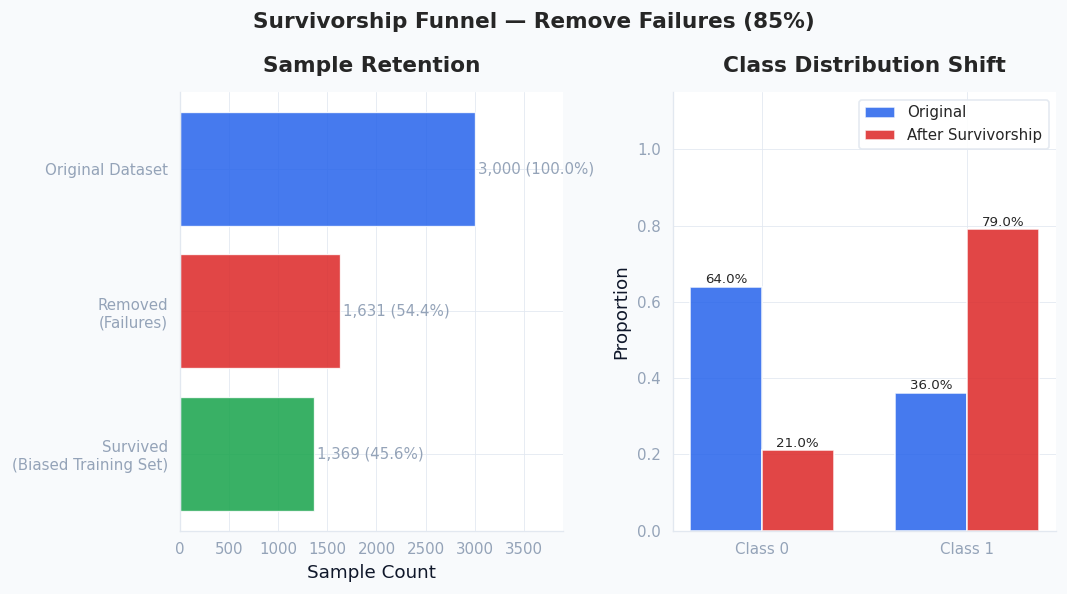

In [8]:
fig, _ = plot_survivorship_funnel(
    biased_surv_a.bias_report,
    title='Survivorship Funnel — Remove Failures (85%)',
)
plt.show()

### Dataset Shift After Removing Failures

Trong experiment này, **85% samples của failure class (class 0)** đã bị loại bỏ để mô phỏng survivorship bias.
Kết quả là **1631 samples bị remove**, làm dataset giảm từ **3000 xuống còn 1369 samples**.

Class distribution thay đổi rất mạnh:

* Original distribution

  * class 0: **1919 (64%)**
  * class 1: **1081 (36%)**

* After survivorship filtering

  * class 0: **288 (21%)**
  * class 1: **1081 (79%)**

Điều này tạo ra một **distribution shift lớn**, trong đó dataset training trở nên **gần như chỉ chứa survivors**.
Tỷ lệ positive/negative tăng từ **0.56 → 3.75**, tương đương **bias magnitude = 3.19x**.

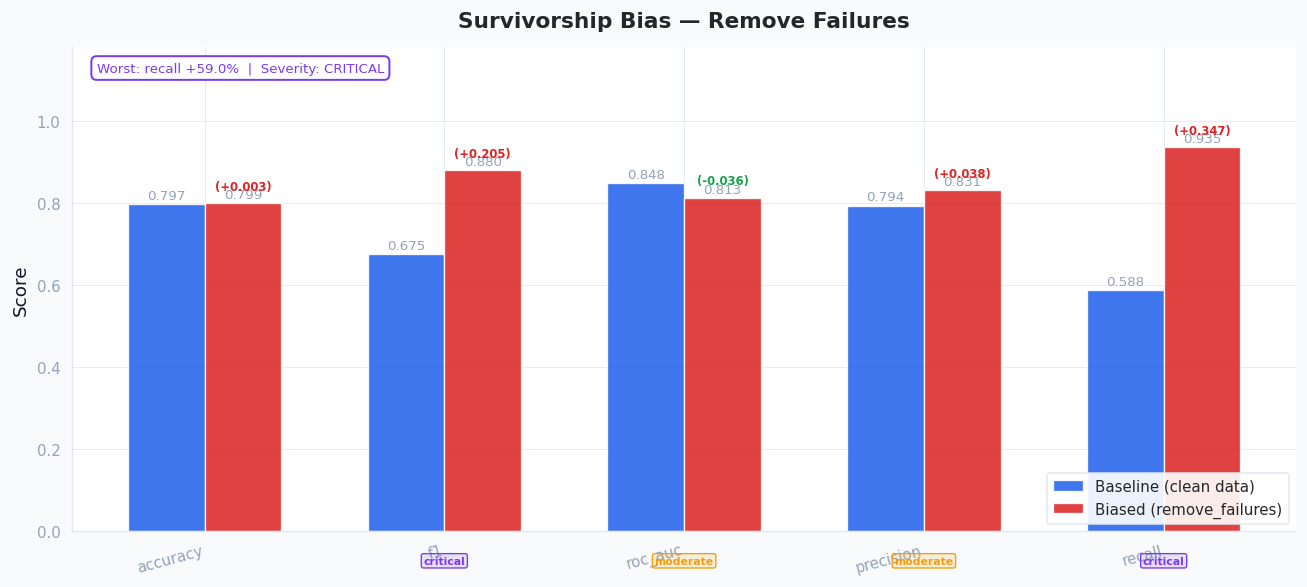

In [9]:
tt_surv_a    = preprocess(biased_surv_a.biased, random_state=RANDOM_STATE)
model_surv_a = train_baseline(tt_surv_a, model_type='logistic_regression', run_cv=False)
report_surv_a = compare_baseline_vs_biased(
    baseline, model_surv_a,
    bias_type='survivorship_bias',
    bias_strategy='remove_failures',
)

fig, _ = plot_bias_impact_bars(report_surv_a, title='Survivorship Bias — Remove Failures')
plt.show()

### Impact on Model Performance

Sau khi dataset bị survivorship bias, các metrics của model thay đổi đáng kể:

| Metric    | Baseline | Biased | Change     |
| --------- | -------- | ------ | ---------- |
| Accuracy  | 0.797    | 0.799  | +0.003     |
| F1 Score  | 0.675    | 0.880  | **+0.205** |
| ROC-AUC   | 0.848    | 0.813  | −0.036     |
| Precision | 0.794    | 0.831  | +0.038     |
| Recall    | 0.588    | 0.935  | **+0.347** |

Metric bị ảnh hưởng mạnh nhất là **recall**, tăng **+59% relative improvement**.
F1-score cũng tăng đáng kể vì model gần như luôn dự đoán **positive class**.

Tuy nhiên, **ROC-AUC giảm**, cho thấy khả năng phân biệt giữa hai class thực chất **không tốt hơn**.

---

### Insight — Illusion of Performance

Survivorship bias có thể tạo ra **ảo giác rằng model đã cải thiện mạnh**, đặc biệt khi nhìn vào các metrics như **recall hoặc F1-score**.

Nguyên nhân là vì dataset sau filtering:

* chứa **rất nhiều positive samples**
* thiếu **failure cases**
* trở nên **dễ hơn cho model dự đoán**

Trong thực tế, model chỉ đang **học distribution bị cắt xén** của survivors.

Khi deploy trên dữ liệu thật — nơi cả **success và failure cases** đều tồn tại — model có thể:

* dự đoán **quá lạc quan**
* bỏ sót nhiều failure cases
* hoạt động kém hơn so với kết quả trong experiment.

Điều này minh họa rõ ràng cách **survivorship bias có thể làm sai lệch việc đánh giá model performance**.

### Strategy B: Look-ahead Bias (Data Leakage)

**Look-ahead bias** là một dạng **data leakage** xảy ra khi model được train bằng những thông tin **chỉ tồn tại trong tương lai**, tức là những dữ liệu chưa có tại thời điểm prediction.

Điều này khiến model học được các pattern **không thể tồn tại trong môi trường thực tế**, dẫn đến performance trong experiment cao bất thường nhưng không thể tái hiện khi deploy.

Một ví dụ phổ biến trong **financial modeling**:

* sử dụng **closing price của ngày T** để dự đoán movement của **ngày T**
* tại thời điểm cần dự đoán (trước khi market đóng cửa), **closing price của ngày T chưa tồn tại**

Do đó model đang vô tình sử dụng **future information**.

Các ví dụ khác của look-ahead bias trong machine learning:

* sử dụng feature được tính từ **toàn bộ dataset**, bao gồm cả future data
* chuẩn hóa dữ liệu (normalization) bằng **statistics của toàn bộ dataset** trước khi split train/test
* tạo feature từ **future events** mà tại thời điểm prediction chưa xảy ra

---

### Mathematical Formulation of Leakage

Trong experiment này, look-ahead bias được mô phỏng bằng cách tạo một **leaked feature** $Z$ có correlation cao với target $Y$:

$$
Z_i = \alpha \cdot (2Y_i - 1) + (1 - \alpha)\epsilon_i
$$

trong đó:

* $Y_i$ là **target label**
* $\epsilon_i \sim \mathcal{N}(0,1)$ là noise ngẫu nhiên
* $\alpha$ là **leakage strength**

Feature $Z$ khi đó chứa **một phần thông tin của target**.

---

### Leakage Strength

Tham số $\alpha$ điều khiển mức độ rò rỉ thông tin:

* $\alpha = 0$
  → $Z$ chỉ là noise, **không chứa thông tin về target**

* $0 < \alpha < 1$
  → $Z$ chứa **một phần thông tin của target**

* $\alpha \rightarrow 1$
  → $Z$ gần như trở thành **bản copy của target**

Khi leakage strength tăng, model sẽ **dễ dàng học được target**, dẫn đến metrics cao bất thường.

---

### Expected Effects on Model Training

Look-ahead bias có thể gây ra các hiện tượng sau:

**1. Unrealistically High Performance**

Model có thể đạt **accuracy hoặc ROC-AUC rất cao**, vì feature đã chứa thông tin của target.

---

**2. Overconfident Predictions**

Do feature gần như "biết trước" outcome, model sẽ đưa ra **prediction với confidence rất cao**.

---

**3. Deployment Failure**

Khi deploy trên dữ liệu thực — nơi leaked feature **không tồn tại** — performance của model sẽ giảm mạnh.

---

### Key Insight

Look-ahead bias là một trong những lỗi nguy hiểm nhất trong machine learning vì:

* rất **dễ xảy ra trong quá trình feature engineering**
* khó phát hiện nếu chỉ nhìn vào metrics
* có thể khiến model trông **gần như hoàn hảo trong experiment**

Do đó, khi xây dựng pipeline ML, cần đảm bảo rằng:

> **Tất cả features đều chỉ sử dụng thông tin có sẵn tại thời điểm prediction.**

In [10]:
biased_surv_b = simulate_survivorship_bias(
    bundle,
    strategy='inject_lookahead_bias',
    n_future_features=3,
    leakage_strength=0.8,
)

print('Warning:', biased_surv_b.bias_report.get('warning'))
print('Injected columns:', biased_surv_b.bias_report.get('injected_columns'))

⚠ Injected 3 look-ahead features (leakage=0.8) — FOR SIMULATION ONLY


Injected columns: ['future_leak_00', 'future_leak_01', 'future_leak_02']


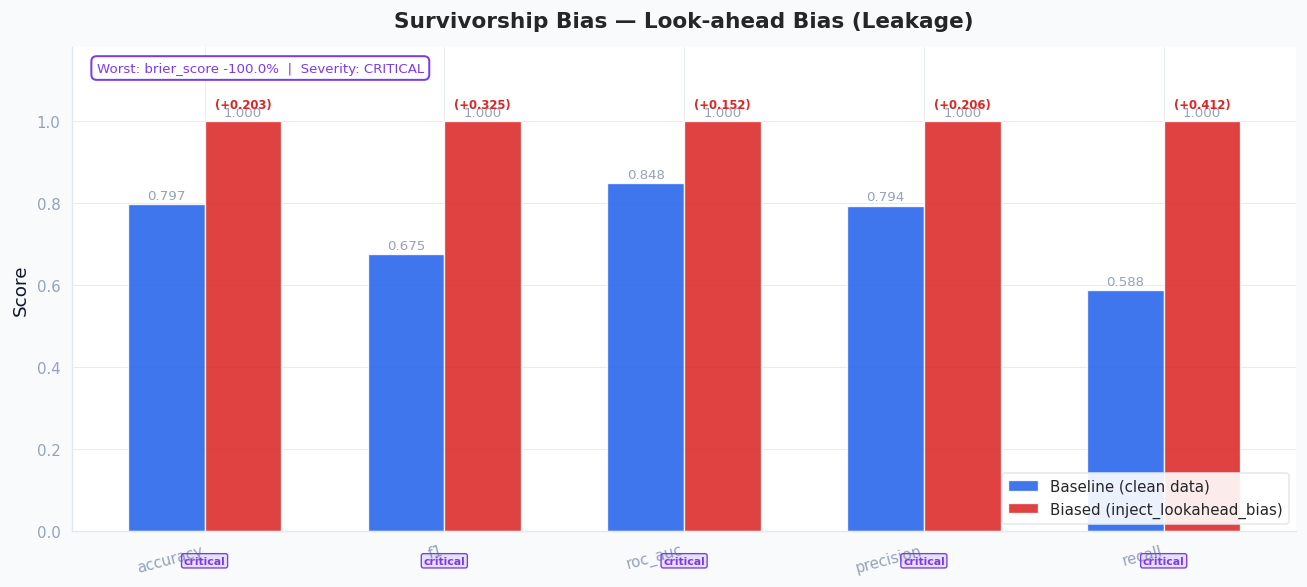

In [11]:
tt_surv_b    = preprocess(biased_surv_b.biased, random_state=RANDOM_STATE)
model_surv_b = train_baseline(tt_surv_b, model_type='logistic_regression', run_cv=False)
report_surv_b = compare_baseline_vs_biased(
    baseline, model_surv_b,
    bias_type='survivorship_bias',
    bias_strategy='inject_lookahead_bias',
)

fig, _ = plot_bias_impact_bars(report_surv_b, title='Survivorship Bias — Look-ahead Bias (Leakage)')
plt.show()

### Performance Inflation Caused by Look-ahead Bias

Trong experiment này, **3 leaked features** (`future_leak_00`, `future_leak_01`, `future_leak_02`) được inject vào dataset với **leakage strength = 0.8**.
Các feature này chứa thông tin có tương quan mạnh với **target variable**, mô phỏng trường hợp model sử dụng **future information** trong quá trình training.

Kết quả là performance của model tăng lên **bất thường**:

| Metric    | Baseline | With Leakage | Change |
| --------- | -------- | ------------ | ------ |
| Accuracy  | 0.797    | **1.000**    | +0.203 |
| F1 Score  | 0.675    | **1.000**    | +0.325 |
| ROC-AUC   | 0.848    | **1.000**    | +0.152 |
| Precision | 0.794    | **1.000**    | +0.206 |
| Recall    | 0.588    | **1.000**    | +0.412 |

Tất cả metrics đều đạt **perfect score (1.0)**, cho thấy model gần như **predict chính xác tuyệt đối** trên dataset.

---

### Interpretation — Perfect Metrics as a Leakage Signal

Trong thực tế, việc đạt **perfect performance trên nhiều metrics cùng lúc** là cực kỳ hiếm trong các bài toán machine learning thực.

Hiện tượng này thường là **strong signal của data leakage**, vì model đã vô tình sử dụng feature chứa thông tin của target.

Trong trường hợp này:

* leaked features gần như **encode trực tiếp outcome**
* model chỉ cần học mapping đơn giản từ feature → target
* bài toán classification trở nên **trivial**

Do đó, metrics cao không phản ánh **khả năng dự đoán thực sự của model**.

---

### Key Insight — Why Look-ahead Bias Is Dangerous

Look-ahead bias là một trong những lỗi nguy hiểm nhất trong machine learning pipeline vì nó:

* tạo ra **ảo giác rằng model hoạt động hoàn hảo**
* che giấu vấn đề cho đến khi model được deploy
* khiến evaluation trở nên **không còn ý nghĩa**

Khi áp dụng model trên dữ liệu thực — nơi các leaked features **không tồn tại** — performance sẽ **giảm mạnh**, thậm chí có thể tệ hơn cả baseline.

Do đó, trong mọi ML pipeline cần đảm bảo rằng:

* feature engineering **không sử dụng thông tin từ tương lai**
* data preprocessing **không làm rò rỉ target**
* train/test split được thực hiện **trước khi tạo các derived features**

---

## 3. Overconfidence Bias

### Concept

**Overconfidence bias** là xu hướng **đánh giá quá cao độ chính xác của predictions và mức độ chắc chắn của mô hình**.

Trong machine learning, bias này xảy ra khi model hoặc analyst **tin rằng predictions của model đáng tin hơn thực tế**.

Overconfidence có thể xuất hiện ở nhiều cấp độ khác nhau trong pipeline ML.

---

### Level 1 — Probability Calibration

Ở cấp độ này, vấn đề nằm ở **probability predictions**.

Ví dụ:

* model dự đoán: **90% probability là class 1**
* nhưng khi kiểm tra thực tế, chỉ **60% predictions đúng**

Khi đó model được gọi là **miscalibrated**.

Một model **well-calibrated** phải thỏa:

> trong tất cả predictions có probability = 0.9, khoảng **90% phải đúng**.

Nếu probability predictions **quá cực đoan so với thực tế**, model đang bị **overconfident**.

---

### Level 2 — Prediction Intervals

Trong regression hoặc probabilistic forecasting, model thường cung cấp **prediction intervals**.

Ví dụ:

* model báo cáo **95% confidence interval**
* nhưng interval chỉ chứa **60% observations thật**

Điều này cho thấy model **đánh giá thấp uncertainty của dữ liệu**.

Nói cách khác, prediction intervals bị **quá hẹp (overly squeezed)** so với uncertainty thực tế.

---

### Level 3 — Metric Reporting

Overconfidence bias cũng có thể xuất hiện ở **cấp độ con người (data scientist)** khi báo cáo kết quả.

Một số ví dụ phổ biến:

* báo cáo **accuracy trên training set** thay vì test set
* chạy experiment nhiều lần nhưng **chỉ report lần tốt nhất**
* tuning hyperparameters trên test set (test set leakage)

Những hành vi này khiến performance trông **tốt hơn thực tế**.

---

### Metric: Expected Calibration Error (ECE)

**Expected Calibration Error (ECE)** đo mức độ lệch giữa **predicted probability** và **actual frequency**.

$$
\text{ECE} =
\sum_{m=1}^{M}
\frac{|B_m|}{n}
\left|
\text{acc}(B_m) - \text{conf}(B_m)
\right|
$$

Trong đó:

* $M$ là số **probability bins** (thường = 10)
* $B_m$ là tập samples có predicted probability rơi vào **bin $m$**
* $\text{acc}(B_m)$ là **tỷ lệ positive samples thực tế** trong bin
* $\text{conf}(B_m)$ là **mean predicted probability** trong bin

Ý nghĩa:

* **ECE = 0** → model perfectly calibrated
* **ECE càng cao** → model càng **miscalibrated / overconfident**

---

### Metric: Brier Score

**Brier Score** là một **proper scoring rule** dùng để đánh giá chất lượng của probability predictions.

$$
\text{BS} =
\frac{1}{n}
\sum_{i=1}^{n}
(\hat{p}_i - y_i)^2
$$

Trong đó:

* $\hat{p}_i$ là predicted probability
* $y_i$ là true label

Diễn giải:

* **BS = 0** → predictions hoàn hảo
* **BS ≈ 0.25** → classifier gần như random (với balanced classes)
* **BS càng lớn** → probability predictions càng kém

Khác với accuracy, **Brier Score phạt rất nặng các predictions rất confident nhưng sai**, nên nó đặc biệt hữu ích để phát hiện **overconfidence**.

---

### Key Insight

Một model có thể đạt **accuracy cao nhưng vẫn bị overconfident** nếu probability predictions không được calibrate tốt.

Do đó trong các hệ thống ML thực tế (đặc biệt là **risk modeling, healthcare, finance**), việc đánh giá model nên bao gồm:

* **calibration metrics (ECE, Brier Score)**
* **reliability diagrams**
* **prediction interval coverage**

để đảm bảo rằng model **không chỉ chính xác, mà còn đáng tin cậy về mặt xác suất**.

### Strategy A: Probability Inflation

Trong strategy này, ta mô phỏng **overconfidence bias** bằng cách **đẩy predicted probabilities về phía các giá trị cực đoan (0 và 1)**.

Ý tưởng là làm cho model trông **rất chắc chắn về predictions**, ngay cả khi mức độ chắc chắn đó **không phản ánh đúng uncertainty của dữ liệu**.

Trong thực tế, hiện tượng này thường xảy ra khi:

* model **overfit vào training data**
* dataset có **label noise nhưng model vẫn predict với confidence rất cao**
* probability outputs **không được calibrate**

---

### Mechanism

Giả sử model ban đầu dự đoán probability:

$$
p_i = P(Y=1 \mid X_i)
$$

Để mô phỏng overconfidence, ta áp dụng một transformation đẩy probability ra xa điểm **0.5**:

$$
p_i' =
\frac{p_i^\gamma}{p_i^\gamma + (1-p_i)^\gamma}
$$

Trong đó:

* $\gamma > 1$ là **confidence amplification factor**

Khi $\gamma$ tăng:

* probabilities gần **0.5** bị đẩy về **0 hoặc 1**
* predictions trở nên **cực đoan hơn**
* model trở nên **overconfident**

---

### Example

Ví dụ:

| Original probability | After inflation |
| -------------------- | --------------- |
| 0.60                 | 0.80            |
| 0.70                 | 0.92            |
| 0.80                 | 0.97            |

Những predictions vốn chỉ **khá chắc chắn** sẽ trở thành **gần như chắc chắn tuyệt đối**.

---

### Expected Effects

Probability inflation có thể dẫn đến các hiện tượng sau:

**1. Accuracy gần như không đổi**

Vì predicted class vẫn giống trước, accuracy thường **không thay đổi nhiều**.

---

**2. Calibration trở nên tệ hơn**

Model trở nên **miscalibrated** vì predicted probability không còn phản ánh đúng frequency thực tế.

Điều này làm:

* **ECE tăng**
* **Brier Score xấu đi**

---

**3. Overconfident errors**

Những predictions sai nhưng có probability rất cao sẽ bị **phạt nặng** bởi Brier Score.

---

### Key Insight

Probability inflation minh họa rằng:

> Một model có thể giữ nguyên accuracy nhưng trở nên **kém đáng tin cậy hơn về mặt xác suất**.

Do đó khi đánh giá model, chỉ nhìn vào **accuracy hoặc F1-score** là không đủ.

Các metrics về **calibration** như **ECE** và **Brier Score** là cần thiết để phát hiện **overconfidence bias**.

In [12]:
oc_result_a = simulate_overconfidence_bias(
    bundle,
    strategy='inflate_probabilities',
    inflation_factor=1.6,
    random_state=RANDOM_STATE,
)

br = oc_result_a.bias_report
print('Original calibration:', br['original_calibration'])
print('Biased calibration  :', br['biased_calibration'])
print('ECE increase        :', br['ece_increase'])

Original calibration: {'ece': 0.0398, 'mce': 0.1532, 'brier_score': 0.1442, 'overconfidence_index': -0.0005, 'mean_predicted_prob': 0.3595, 'mean_actual_rate': 0.36}
Biased calibration  : {'ece': 0.0701, 'mce': 0.1074, 'brier_score': 0.148, 'overconfidence_index': -0.0446, 'mean_predicted_prob': 0.3154, 'mean_actual_rate': 0.36}
ECE increase        : 0.0303


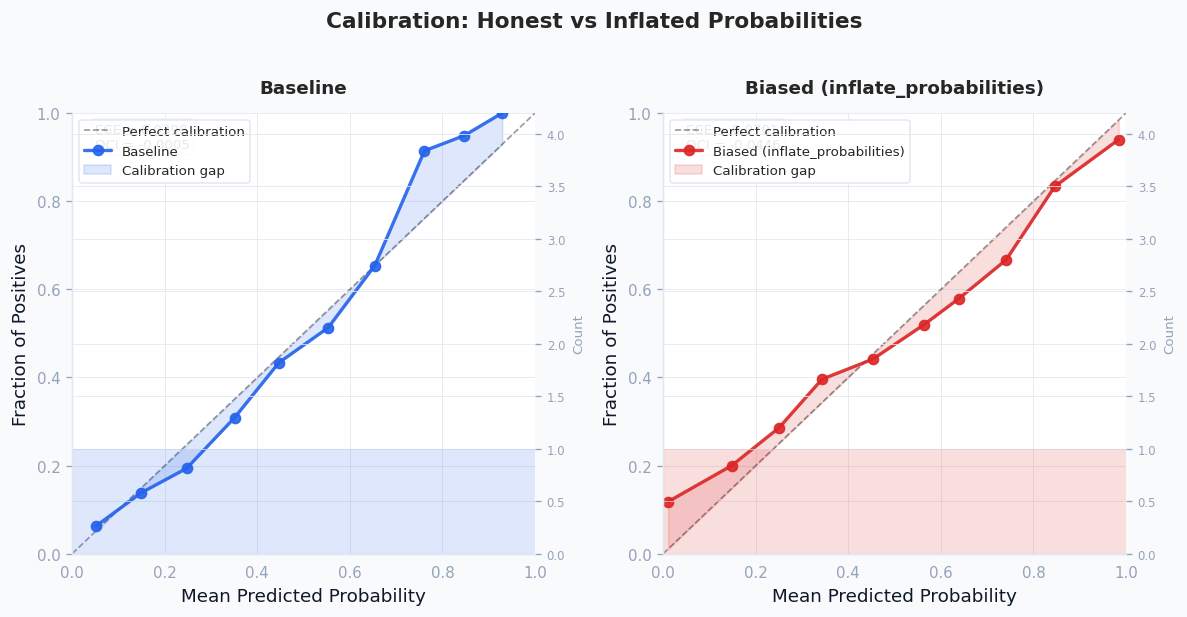

In [13]:
orig_cal  = compute_calibration_metrics(oc_result_a.y_true, oc_result_a.y_proba_original)
biased_cal = compute_calibration_metrics(oc_result_a.y_true, oc_result_a.y_proba_biased)

from src.metrics.evaluation import ComparisonReport
fake_report = ComparisonReport(
    bias_type='overconfidence_bias',
    bias_strategy='inflate_probabilities',
    baseline_calibration=orig_cal,
    biased_calibration=biased_cal,
)

fig, _ = plot_calibration_comparison(
    fake_report,
    title='Calibration: Honest vs Inflated Probabilities',
)
plt.show()

### Calibration Shift After Probability Inflation

Biểu đồ calibration cho thấy sự khác biệt giữa **baseline probabilities** và **inflated probabilities** sau khi áp dụng probability inflation.

Ở model baseline, đường calibration nằm khá gần đường **perfect calibration (y = x)**, cho thấy predicted probabilities tương đối phản ánh đúng tần suất xảy ra thực tế.

Sau khi probability inflation được áp dụng, predicted probabilities bị **đẩy về các giá trị cực đoan hơn**, làm cho đường calibration **lệch xa hơn khỏi đường perfect calibration**.

Điều này cho thấy model trở nên **miscalibrated** — mức độ chắc chắn trong prediction không còn phản ánh đúng xác suất thực tế của outcome.

---

### Quantitative Impact on Calibration Metrics

Các metrics calibration cho thấy sự suy giảm rõ rệt sau khi probabilities bị inflate:

| Metric                     | Baseline | Inflated | Change      |
| -------------------------- | -------- | -------- | ----------- |
| ECE                        | 0.0398   | 0.0701   | **+0.0303** |
| MCE                        | 0.1532   | 0.1074   | −0.0458     |
| Brier Score                | 0.1442   | 0.1480   | **+0.0038** |
| Mean predicted probability | 0.3595   | 0.3154   | −0.0441     |
| Mean actual rate           | 0.3600   | 0.3600   | 0           |

Đặc biệt:

* **ECE tăng ~76%**, cho thấy calibration của model trở nên kém hơn đáng kể
* **Brier Score tăng**, nghĩa là quality của probability predictions giảm
* **Mean predicted probability giảm**, trong khi **actual rate giữ nguyên**

Điều này chứng tỏ distribution của predicted probabilities đã bị **distort**.

---

### Insight — Accuracy May Stay the Same but Confidence Becomes Wrong

Probability inflation minh họa một hiện tượng quan trọng trong machine learning:

> Model có thể giữ nguyên classification accuracy nhưng trở nên **kém đáng tin cậy hơn về mặt xác suất**.

Các predictions trở nên **quá tự tin (overconfident)**, đặc biệt với những cases gần decision boundary.

Trong các hệ thống cần **risk estimation hoặc decision making** (finance, healthcare, autonomous systems), việc miscalibration như vậy có thể gây ra các quyết định sai lầm.

Do đó, ngoài accuracy và F1-score, việc đánh giá model nên bao gồm các **calibration metrics như ECE và Brier Score** để phát hiện **overconfidence bias**.

### Strategy B: Metric Hacking

**Metric hacking** (hay **p-hacking** trong thống kê) là hiện tượng khi analyst thực hiện **nhiều lần thử nghiệm khác nhau** — ví dụ thay đổi random seeds, train nhiều model, hoặc thử nhiều cấu hình — nhưng chỉ **báo cáo kết quả tốt nhất**.

Điều này tạo ra ảo giác rằng model có performance cao hơn thực tế, vì kết quả được chọn đã **tận dụng random variation của experiment**.

Trong machine learning, metric hacking thường xảy ra khi:

* chạy model với **nhiều random seeds**
* thử nhiều **hyperparameter configurations**
* train nhiều lần rồi **chỉ report run tốt nhất**
* tuning model trực tiếp trên **test set**

Những hành vi này làm cho evaluation trở nên **không còn unbiased**.

---

### Statistical Perspective

Giả sử ta chạy $n$ experiments độc lập và mỗi lần thu được một metric $X_i$.

Nếu ta chọn **kết quả tốt nhất** để báo cáo, thì kỳ vọng của giá trị được chọn sẽ lớn hơn kỳ vọng của một trial đơn lẻ:

$$
E[\max(X_1, ..., X_n)] > E[X_i]
$$

Điều này xảy ra vì khi số trials tăng lên, xác suất xuất hiện **một kết quả ngẫu nhiên rất tốt** cũng tăng lên.

Trong nhiều trường hợp, độ chênh lệch giữa **best result** và **true expected performance** tăng theo:

$$
O(\log n)
$$

Do đó, càng chạy nhiều experiments, kết quả được report càng dễ bị **inflated**.

---

### Example Scenario

Giả sử một model có accuracy thật sự khoảng **0.80**.

Nếu chạy:

* 1 experiment → accuracy ≈ **0.80**
* 20 experiments → có thể xuất hiện run với **0.84**
* 100 experiments → có thể xuất hiện run với **0.87**

Nếu chỉ report **best run**, người đọc sẽ tin rằng model đạt **0.87 accuracy**, trong khi performance thực tế chỉ khoảng **0.80**.

---

### Consequences

Metric hacking có thể dẫn đến:

* **overestimated model performance**
* kết luận sai về **model improvements**
* difficulty trong việc **reproduce results**

Trong research, hiện tượng này là một trong những nguyên nhân chính của **replication crisis**.

---

### Mitigation Strategies

Để tránh metric hacking, nên áp dụng các phương pháp sau:

**1. Report Mean ± Standard Deviation**

Thay vì report best run, nên báo cáo:

```
accuracy = mean ± std over multiple trials
```

---

**2. Fix Random Seeds or Pre-register Experiments**

Định nghĩa trước số lượng experiments và không chọn lọc kết quả sau khi chạy.

---

**3. Multiple Comparison Correction**

Trong thống kê, có thể dùng các phương pháp như **Bonferroni correction** để điều chỉnh khi thực hiện nhiều tests.

---

### Key Insight

Metric hacking không làm thay đổi model, nhưng làm thay đổi **cách kết quả được báo cáo**.

Do đó, một model có thể trông **tốt hơn đáng kể trên paper hoặc report**, trong khi performance thực tế **không hề cải thiện**.

Việc đánh giá model một cách minh bạch — báo cáo **toàn bộ distribution của results** thay vì chỉ best case — là cần thiết để tránh **overconfidence bias trong model evaluation**.

In [14]:
oc_result_b = simulate_overconfidence_bias(
    bundle,
    strategy='simulate_metric_hacking',
    n_trials=20,
    metric='roc_auc',
    random_state=RANDOM_STATE,
)

br_b = oc_result_b.bias_report
print(f'Honest score   : {br_b["honest_score"]:.4f}')
print(f'Reported score : {br_b["reported_score"]:.4f}')
print(f'Inflation      : +{br_b["inflation_pct"]:.2f}%')
print(f'Interpretation : {br_b["interpretation"]}')

Honest score   : 0.8185
Reported score : 0.8185
Inflation      : +0.00%
Interpretation : Báo cáo roc_auc=0.8185 thay vì honest estimate 0.8185 — inflate 0.0%


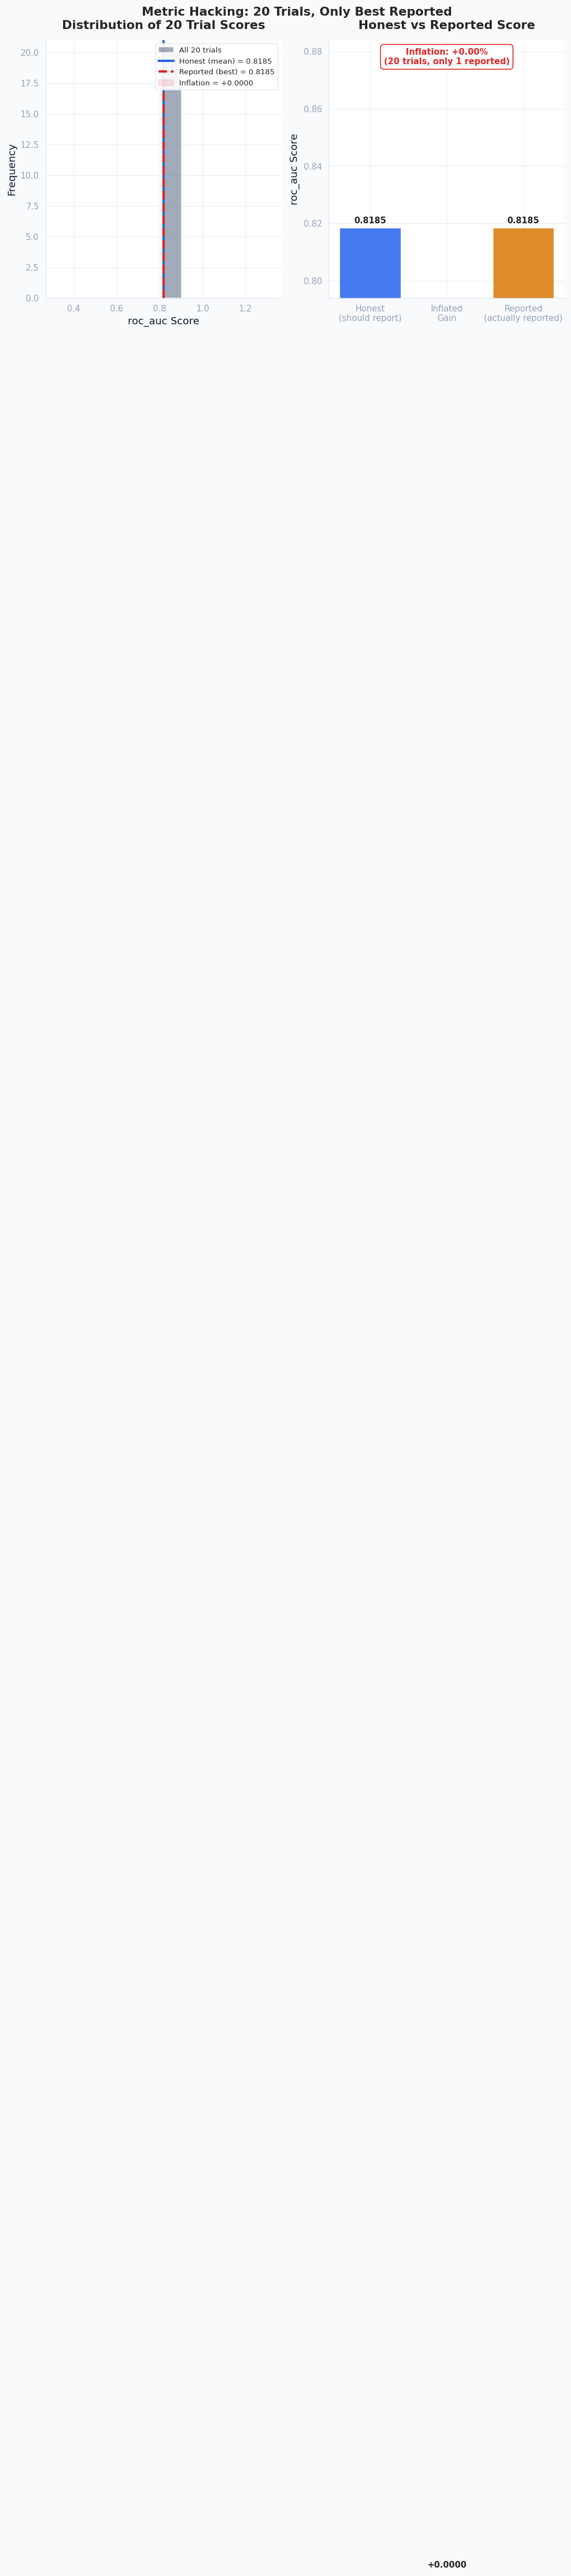

In [15]:
fig, _ = plot_metric_hacking_distribution(
    br_b,
    title='Metric Hacking: 20 Trials, Only Best Reported',
)
plt.show()

### Distribution of Trial Results

Trong experiment này, model được train **20 lần với các random seeds khác nhau** để mô phỏng quá trình thử nghiệm nhiều lần trong thực tế.

Histogram bên trái cho thấy **distribution của roc_auc scores qua 20 trials**.
Các kết quả tập trung quanh **0.8185**, cho thấy performance của model khá ổn định giữa các runs.

Điều quan trọng là performance thực sự của model nên được báo cáo dưới dạng:

```
roc_auc ≈ 0.8185 (mean across trials)
```

thay vì chọn một run cụ thể.

---

### Honest Score vs Reported Score

Biểu đồ bên phải so sánh:

* **Honest score** — mean performance trên toàn bộ trials
* **Reported score** — kết quả tốt nhất được chọn để báo cáo

Trong experiment này:

| Metric                    | Value     |
| ------------------------- | --------- |
| Honest score (mean)       | 0.8185    |
| Reported score (best run) | 0.8185    |
| Inflation                 | **0.00%** |

Do distribution của các trials khá hẹp, best run không khác đáng kể so với mean.

---

### Insight — Why Metric Hacking Is Still Risky

Mặc dù experiment này không tạo ra inflation đáng kể, **metric hacking vẫn là một rủi ro lớn trong practice**.

Khi số lượng trials tăng lên:

* distribution của results trở nên **rộng hơn**
* xác suất xuất hiện một **outlier run với score cao** tăng lên
* reported score dễ bị **inflate so với expected performance**

Do đó trong model evaluation nên:

* báo cáo **mean ± std qua nhiều runs**
* tránh chỉ report **best result**
* đảm bảo evaluation process **minh bạch và reproducible**

Điều này giúp tránh **overconfidence bias trong model reporting**.

---

## 4. Comparing the Impact of Different Biases

### Concept: Severity Scale

Để so sánh mức độ ảnh hưởng giữa các loại bias khác nhau, project sử dụng **relative change** của các metrics so với baseline model.

Relative change đo mức độ **metrics thay đổi bao nhiêu phần trăm** sau khi bias được introduce vào dataset hoặc pipeline.

Công thức được sử dụng:

$$
\text{Relative Change} =
\frac{\text{metric}*{\text{biased}} - \text{metric}*{\text{baseline}}}
{\text{metric}_{\text{baseline}}}
\times 100%
$$

Trong đó:

* $\text{metric}_{\text{baseline}}$ là performance của model trên **clean dataset**
* $\text{metric}_{\text{biased}}$ là performance sau khi **bias được introduce**

Chỉ số này giúp chuẩn hóa việc so sánh giữa các metrics khác nhau như:

* accuracy
* F1-score
* ROC-AUC
* recall
* calibration metrics

---

### Severity Classification

Để diễn giải mức độ ảnh hưởng của bias một cách trực quan hơn, project sử dụng **severity scale** dựa trên relative change của metric.

| Severity   | Relative Change |
| ---------- | --------------- |
| Negligible | < 1%            |
| Minor      | 1 – 3%          |
| Moderate   | 3 – 7%          |
| Severe     | 7 – 15%         |
| Critical   | > 15%           |

Ý nghĩa của các mức severity:

* **Negligible**: bias gần như không ảnh hưởng đến model performance
* **Minor**: ảnh hưởng nhỏ, thường nằm trong mức noise của experiment
* **Moderate**: bắt đầu có tác động rõ rệt đến evaluation metrics
* **Severe**: bias làm thay đổi đáng kể kết quả của model
* **Critical**: bias làm metrics **mất hoàn toàn ý nghĩa**, thường dẫn đến kết luận sai

---

### Purpose of the Severity Scale

Severity scale giúp:

* so sánh **mức độ nguy hiểm của các loại bias khác nhau**
* định lượng mức độ **metric distortion**
* cung cấp một cách **trực quan để đánh giá robustness của model evaluation**

Thông qua thang đo này, project có thể xác định:

* bias nào gây **distortion mạnh nhất**
* bias nào chỉ tạo ra **những thay đổi nhỏ trong metrics**
* bias nào có thể dẫn đến **sai lệch nghiêm trọng trong model evaluation**.

In [16]:
from src import build_summary_table, print_summary

all_reports = [report_a, report_b, report_surv_a, report_surv_b]

print_summary(all_reports)


════════════════════════════════════════════════════════════════════════════════
  BIAS IMPACT SUMMARY
════════════════════════════════════════════════════════════════════════════════

  [confirmation_bias/cherry_pick_features] Severity: SEVERE | Worst metric: brier_score (0.1442 → 0.1601, +11.0%, deflated)
  Statistical test: Không có sự khác biệt có ý nghĩa thống kê (p=0.0896, α=0.05). Effect size: 0.1429 (medium).

  [confirmation_bias/filter_confirming_samples] Severity: CRITICAL | Worst metric: recall (0.5880 → 0.7373, +25.4%, inflated)

  [survivorship_bias/remove_failures] Severity: CRITICAL | Worst metric: recall (0.5880 → 0.9352, +59.0%, inflated)

  [survivorship_bias/inject_lookahead_bias] Severity: CRITICAL | Worst metric: brier_score (0.1442 → 0.0000, -100.0%, inflated)
  Statistical test: Có sự khác biệt có ý nghĩa thống kê (p=0.0000, α=0.05). Effect size: 0.5000 (large).

────────────────────────────────────────────────────────────────────────────────
  TOP IMPACTED MET

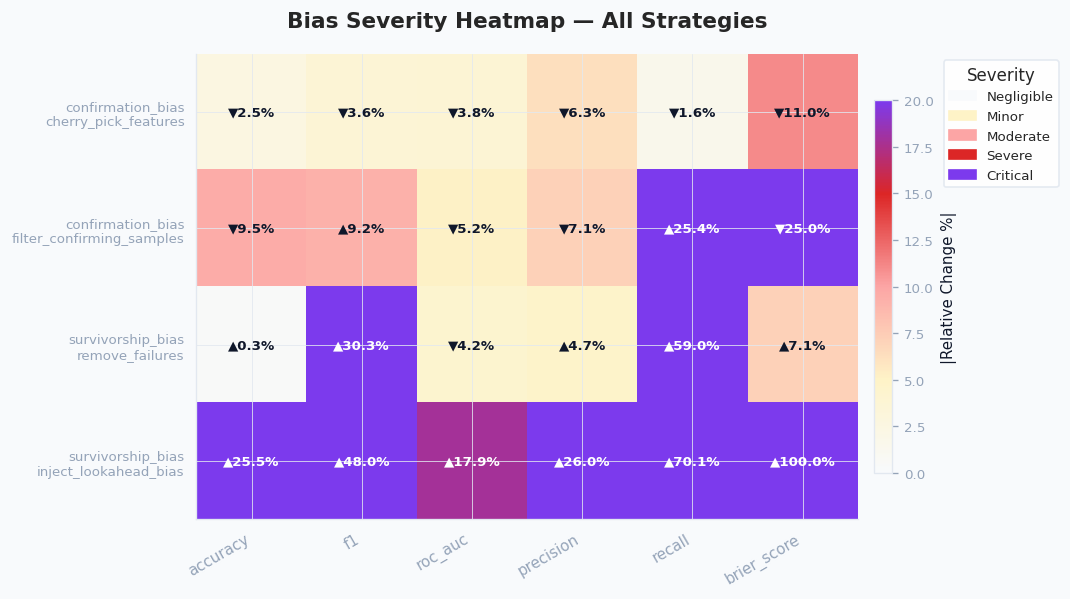

In [17]:
from src import plot_severity_heatmap

fig, _ = plot_severity_heatmap(
    all_reports,
    title='Bias Severity Heatmap — All Strategies',
)
plt.show()

In [18]:
df_summary = build_summary_table(all_reports)

pivot = df_summary.pivot_table(
    index='strategy',
    columns='metric',
    values='rel_pct',
    aggfunc='first',
).round(2)

display(pivot)

metric,accuracy,avg_precision,brier_score,f1,log_loss,mcc,precision,recall,roc_auc
strategy,,,,,,,,,
cherry_pick_features,-2.51,-6.19,11.03,-3.63,9.21,-8.44,-6.26,-1.58,-3.77
filter_confirming_samples,-9.46,4.90,24.97,9.15,18.16,-19.16,-7.11,25.39,-5.15
inject_lookahead_bias,25.52,24.05,-100.00,48.04,-99.76,83.52,25.99,70.07,17.87
remove_failures,0.33,16.76,-7.14,30.30,-8.42,-45.97,4.74,59.05,-4.18


### Bias Severity Comparison Across Strategies

Heatmap trên tổng hợp **relative change (%) của các metrics** khi các loại bias khác nhau được introduce vào pipeline.
Mỗi hàng tương ứng với một **bias strategy**, và mỗi cột là một **evaluation metric**.

Kết quả cho thấy các biases có **tác động rất khác nhau lên từng metric**.

* **Feature cherry-picking** tạo ra thay đổi tương đối nhỏ (≈2–11%), chủ yếu ảnh hưởng đến **Brier Score** và **precision**.
* **Sample filtering** làm thay đổi đáng kể **recall (+25.4%)**, cho thấy dataset shift có thể làm model **predict positive nhiều hơn**.
* **Removing failures (survivorship bias)** gây distortion mạnh hơn, đặc biệt với **recall (+59%)** và **F1 (+30%)**.
* **Look-ahead bias (data leakage)** tạo ra ảnh hưởng cực đoan nhất, với nhiều metrics đạt **perfect scores**.

---

### Bias Impact Summary

Tổng hợp từ các experiments cho thấy:

| Bias Strategy             | Severity | Worst Metric | Relative Change |
| ------------------------- | -------- | ------------ | --------------- |
| Cherry-pick features      | Severe   | Brier Score  | +11.0%          |
| Filter confirming samples | Critical | Recall       | +25.4%          |
| Remove failures           | Critical | Recall       | +59.0%          |
| Inject look-ahead bias    | Critical | Brier Score  | −100.0%         |

Đặc biệt:

* **Look-ahead bias** làm **Brier Score giảm từ 0.1442 xuống 0**, cho thấy model gần như **predict hoàn hảo** do leakage.
* **Survivorship bias** làm recall tăng mạnh vì dataset **thiên về positive cases**.

---

### Top Impacted Metrics

Khi tổng hợp tất cả các biases, những metrics bị ảnh hưởng mạnh nhất là:

| Metric   | Example Change |
| -------- | -------------- |
| MCC      | +83.5%         |
| Recall   | +70.1%         |
| Recall   | +59.0%         |
| F1-score | +48.0%         |
| F1-score | +30.3%         |

Điều này cho thấy **recall và F1-score là các metrics dễ bị inflate nhất khi dataset bị bias**.

---

### Key Insight

So sánh giữa các strategies cho thấy:

1. **Confirmation bias** thường gây distortion vừa phải nhưng khó phát hiện.
2. **Survivorship bias** có thể làm metrics **tăng mạnh do distribution shift**.
3. **Look-ahead bias (data leakage)** là loại bias nguy hiểm nhất vì nó có thể khiến model đạt **perfect performance một cách giả tạo**.

Do đó trong thực tế:

* evaluation nên dựa trên **multiple metrics**
* cần kiểm tra **data leakage và dataset shift**
* và phải đảm bảo pipeline **phản ánh đúng điều kiện deploy thực tế**.

---
## 5. Summary

Notebook này mô phỏng và so sánh 3 loại behavioral bias xuất hiện ở **data level** trong machine learning pipeline.

| Bias | Strategy | Cơ chế | Metric bị ảnh hưởng chính |
|---|---|---|---|
| Confirmation | Cherry-pick features | Chỉ giữ features ủng hộ hypothesis | Accuracy, F1 |
| Confirmation | Sample filtering | Loại samples class không mong muốn | Precision, Recall |
| Survivorship | Remove failures | Bỏ qua failure class | Recall, F1, class distribution |
| Survivorship | Look-ahead | Inject future information | AUC, F1, Recall (near-perfect) |
| Overconfidence | Inflate probabilities | Squeeze probabilities về extremes | ECE, Brier Score |
| Overconfidence | Metric hacking | Chọn best-of-N experiment | AUC inflate |

Các experiments cho thấy rằng **bias ở data level có thể làm thay đổi đáng kể model evaluation**, từ những distortion nhỏ (feature selection) đến các trường hợp cực đoan như **data leakage**, nơi model đạt performance gần như hoàn hảo một cách giả tạo.

Notebook tiếp theo sẽ chuyển sang một loại bias khác:
bias xảy ra trong **model selection process** — không phải ở data, mà ở cách data scientist **tuning, chọn và báo cáo model performance**.